<a href="https://colab.research.google.com/github/cleanesantos/aulas-modelos-datascience/blob/main/Regressao_Linear_Simples_Aula_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão linear: publicidade, vendas e preços de imóveis
## iCEV | Aula prática em Python

**Parte 1:** regressão linear simples para analisar a relação entre investimento em publicidade na TV e vendas.

**Parte 2:** regressão linear simples e múltipla para analisar a relação entre área, localização e valor dos imóveis.

Abra o arquivo no Google Colab pela opção de upload de notebook. As duas bases de dados estão incorporadas ao arquivo. Não é necessário baixar ou enviar CSVs.

Execute as células na ordem ou selecione **Ambiente de execução > Executar tudo**.

### Bases de dados disponiveis no Kaggle.

### Bases de dados disponíveis no repositório da disciplina

- **Publicidade e vendas:** [advertising.csv](https://github.com/cleanesantos/aulas-modelos-datascience/blob/main/advertising.csv).


- **Imóveis:** [dataset.csv](https://github.com/cleanesantos/aulas-modelos-datascience/blob/main/dataset.csv).

## 1. O que queremos estimar?
Uma regressão descreve uma associação entre uma variável resposta e uma ou mais variáveis explicativas.

$$Y_i=\beta_0+\beta_1X_i+\varepsilon_i$$

$$\widehat{Y}_i=\widehat{\beta}_0+\widehat{\beta}_1X_i$$

**X:** variável explicativa.

**Y:** variável resposta.

**Intercepto:** previsão quando X = 0.

**Coeficiente angular:** variação na previsão associada ao aumento de uma unidade em X.

**Resíduo:** observado menos previsto.

A regressão, por si só, não demonstra causalidade.

## 2. Bibliotecas
Pandas organiza as tabelas; Matplotlib e Seaborn produzem gráficos; scikit-learn ajusta e avalia os modelos; statsmodels apresenta resultados estatísticos.

In [10]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)

# Parte 1. Publicidade na TV e vendas

**Pergunta:** maiores investimentos em TV estão associados a maiores vendas?

Utilizaremos a base Advertising, com 200 observações, disponível no repositório da disciplina. Os nomes das variáveis foram traduzidos para facilitar a leitura.

A base contém investimentos em publicidade na TV, no rádio e em jornais, expressos em milhares de dólares, e vendas, expressas em milhares de unidades.

Nesta primeira parte, ajustaremos uma regressão linear simples, utilizando o investimento em TV como variável explicativa e as vendas como variável resposta.

Kaggle: https://www.kaggle.com/datasets/yasserh/advertising-sales-dataset/data


In [15]:
url = "https://raw.githubusercontent.com/cleanesantos/aulas-modelos-datascience/main/advertising.csv"

publicidade = pd.read_csv(url)

publicidade = publicidade.rename(columns={
    "Newspaper": "Jornal",
    "Sales": "Vendas"
})


## 3. Conhecendo a tabela
Cada linha corresponde a uma observação. TV, Radio e Jornal são investimentos em canais de publicidade; Vendas é a resposta. Nesta primeira parte, apenas TV entra no modelo.

In [16]:
print("Linhas e colunas:", publicidade.shape)
publicidade.info()
display(publicidade.isna().sum().to_frame("Ausentes"))
display(publicidade.describe().round(2))

Linhas e colunas: (200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Radio   200 non-null    float64
 2   Jornal  200 non-null    float64
 3   Vendas  200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,Ausentes
TV,0
Radio,0
Jornal,0
Vendas,0


,TV,Radio,Jornal,Vendas
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,15.13
std,85.85,14.85,21.78,5.28
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,11.00
50%,149.75,22.90,25.75,16.00
75%,218.82,36.52,45.10,19.05
max,296.40,49.60,114.00,27.00


## 4. Dispersão e correlação
A dispersão permite observar direção, forma e pontos afastados. A correlação de Pearson resume a associação linear, entre −1 e 1. Correlação alta não prova que aumentar o orçamento causa aumento das vendas.

###TV e Vendas

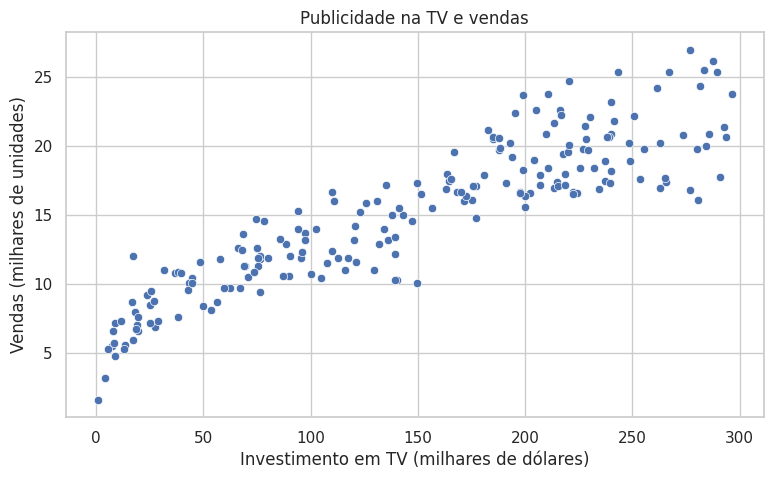

Correlação: 0.9012


In [17]:
sns.scatterplot(data=publicidade, x="TV", y="Vendas")
plt.title("Publicidade na TV e vendas")
plt.xlabel("Investimento em TV (milhares de dólares)")
plt.ylabel("Vendas (milhares de unidades)")
plt.show()

print("Correlação:", round(publicidade["TV"].corr(publicidade["Vendas"]), 4))

O gráfico indica uma associação positiva entre investimento em TV e vendas: observações com maior investimento tendem a apresentar maiores vendas.

A dispersão dos pontos mostra que investimentos semelhantes podem estar associados a vendas diferentes. Portanto, o investimento em TV não explica sozinho toda a variação das vendas.

Essa associação não permite concluir, por si só, que aumentar o investimento em TV causa o aumento das vendas.

###Jornal e Vendas

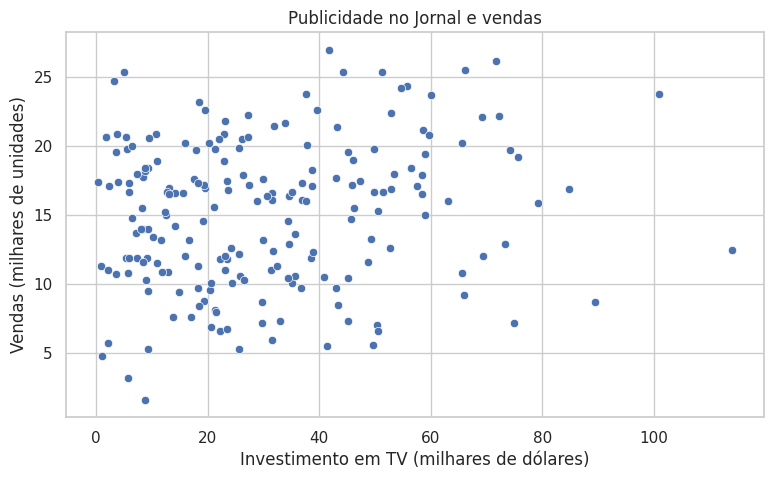

Correlação: 0.158


In [19]:
sns.scatterplot(data=publicidade, x="Jornal", y="Vendas")
plt.title("Publicidade no Jornal e vendas")
plt.xlabel("Investimento em Jornal (milhares de dólares)")
plt.ylabel("Vendas (milhares de unidades)")
plt.show()

print("Correlação:", round(publicidade["Jornal"].corr(publicidade["Vendas"]), 4))

A correlação de 0,158 indica uma associação linear positiva fraca entre investimento em jornal e vendas nesta base. O investimento em jornal, isoladamente, apresenta pouca relação linear com as vendas. Esse resultado não permite concluir que a publicidade em jornal não tenha efeito sobre as vendas.

###Radio e Vendas

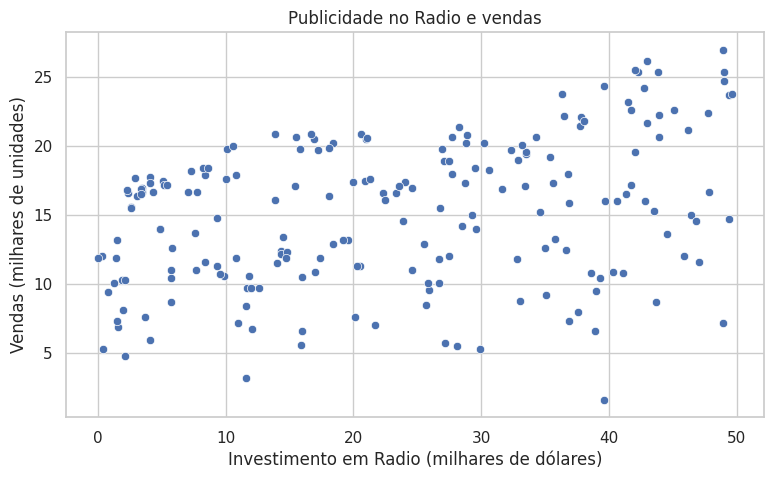

Correlação: 0.3496


In [20]:
sns.scatterplot(data=publicidade, x="Radio", y="Vendas")
plt.title("Publicidade no Radio e vendas")
plt.xlabel("Investimento em Radio (milhares de dólares)")
plt.ylabel("Vendas (milhares de unidades)")
plt.show()

print("Correlação:", round(publicidade["Radio"].corr(publicidade["Vendas"]), 4))

A correlação de 0,3496 indica uma associação linear positiva de intensidade limitada entre investimento em rádio e vendas: investimentos maiores tendem a estar associados a vendas maiores, mas há bastante variação nessa relação.

###Matriz de Correlacao Geral

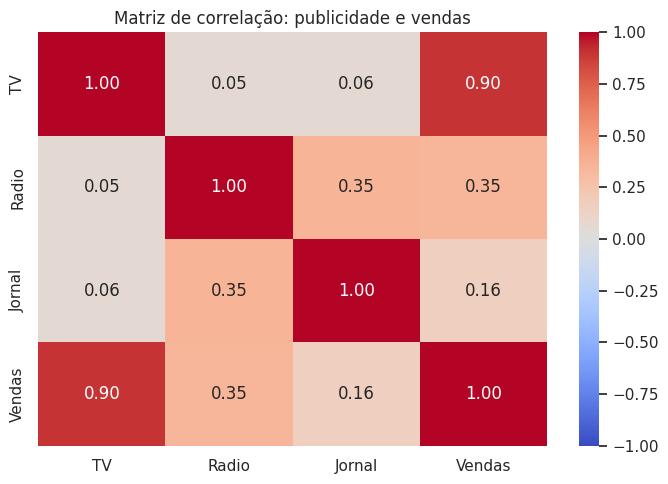

In [22]:
correlacao = publicidade[["TV", "Radio", "Jornal", "Vendas"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Matriz de correlação: publicidade e vendas")
plt.tight_layout()
plt.show()

## 5. Separando treino e teste
Ajustamos os parâmetros no treino (70%) e avaliamos previsões no teste (30%). O teste permanece separado do ajuste. `random_state` torna a divisão reproduzível. Esta divisão aleatória pressupõe observações compatíveis com esse procedimento; dados temporais exigiriam outra divisão.

Obs:A divisão usa a biblioteca `Scikit-learn`, com a função `train_test_split` do módulo `model_selection`

In [23]:
X_publicidade = publicidade[["TV"]]
y_publicidade = publicidade["Vendas"]
X_pub_treino, X_pub_teste, y_pub_treino, y_pub_teste = train_test_split(
    X_publicidade, y_publicidade, test_size=0.30, random_state=100
)
print("Treino:", len(X_pub_treino), "| Teste:", len(X_pub_teste))

## 6. Ajustando a regressão simples
`fit()` estima os parâmetros por mínimos quadrados: minimiza a soma dos resíduos ao quadrado no treino.

biblioteca `Scikit-learn`

In [24]:
modelo_publicidade = LinearRegression()
modelo_publicidade.fit(X_pub_treino, y_pub_treino)

b0 = modelo_publicidade.intercept_
b1 = modelo_publicidade.coef_[0]

print(f"Intercepto (b0): {b0:.4f}")
print(f"Coeficiente de TV (b1): {b1:.4f}")

Intercepto (b0): 6.9487
Coeficiente de TV (b1): 0.0545


### Interpretação dos parâmetros

O modelo ajustado apresenta a equação:

$$
\widehat{\text{Vendas}} = 6{,}9487 + 0{,}0545 \times \text{TV}
$$

**Intercepto ($b_0 = 6{,}9487$):** quando o investimento em TV é zero, o modelo prevê vendas de aproximadamente **6,95 mil unidades**. Esse valor exige cautela, pois o investimento zero está fora do intervalo observado na base.

**Coeficiente de TV ($b_1 = 0{,}0545$):** cada **US$ 1.000 adicionais em publicidade na TV** estão associados a um aumento de **0,0545 mil unidades nas vendas previstas**, equivalente a aproximadamente **54,5 unidades**.

O coeficiente positivo indica uma relação crescente entre investimento em TV e vendas previstas. Essa associação não comprova causalidade.

## 7. Reta ajustada
A reta foi estimada somente no treino. Os pontos do teste permitem comparar a previsão com observações não usadas no ajuste.

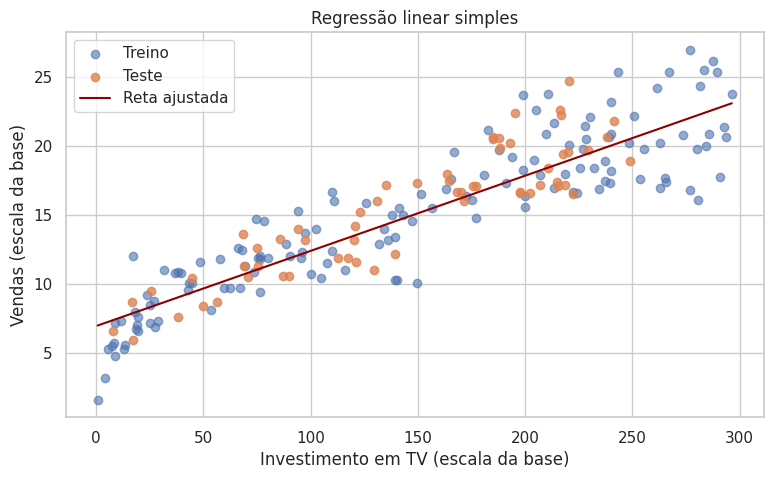

In [25]:
grade_tv = pd.DataFrame({"TV": np.linspace(X_publicidade["TV"].min(), X_publicidade["TV"].max(), 100)})
plt.scatter(X_pub_treino["TV"], y_pub_treino, alpha=0.6, label="Treino")
plt.scatter(X_pub_teste["TV"], y_pub_teste, alpha=0.8, label="Teste")
plt.plot(grade_tv["TV"], modelo_publicidade.predict(grade_tv), color="darkred", label="Reta ajustada")
plt.xlabel("Investimento em TV (escala da base)")
plt.ylabel("Vendas (escala da base)")
plt.title("Regressão linear simples")
plt.legend()
plt.show()

### Interpretação da reta ajustada

A reta apresenta inclinação positiva: quanto maior o investimento em TV, maiores são as vendas previstas pelo modelo. Os pontos acima da reta representam vendas superiores às previstas; os pontos abaixo representam vendas inferiores às previstas. A distância vertical entre os pontos e a reta indica o tamanho dos erros de previsão.

A reta foi ajustada com os dados de treino. A qualidade das previsões será avaliada pelas métricas calculadas no conjunto de teste.

## 8. Avaliando previsões
**MAE:** erro absoluto médio, na escala de Y.

**RMSE:** raiz do erro quadrático médio, também na escala de Y; penaliza mais os erros grandes.

**R²:** compara o erro do modelo ao de prever a média de Y no conjunto avaliado. Pode ser negativo no teste. Não é porcentagem de acertos.

In [26]:
prev_pub = modelo_publicidade.predict(X_pub_teste)

print("R²:", round(r2_score(y_pub_teste, prev_pub), 4))
print("MAE:", round(mean_absolute_error(y_pub_teste, prev_pub), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_pub_teste, prev_pub)), 4))

comparacao = pd.DataFrame()
comparacao["TV"] = X_pub_teste["TV"]
comparacao["Vendas observadas"] = y_pub_teste
comparacao["Vendas previstas"] = prev_pub
comparacao["Resíduo"] = y_pub_teste - prev_pub

comparacao.head(10).round(2)

R²: 0.7921
MAE: 1.6481
RMSE: 2.0193


,TV,Vendas observadas,Vendas previstas,Resíduo
126,7.8,6.6,7.37,-0.77
104,238.2,20.7,19.94,0.76
99,135.2,17.2,14.32,2.88
92,217.7,19.4,18.82,0.58
111,241.7,21.8,20.13,1.67
167,206.8,17.2,18.23,-1.03
116,139.2,12.2,14.54,-2.34
96,197.6,16.7,17.73,-1.03
52,216.4,22.6,18.75,3.85
69,216.8,22.3,18.77,3.53


### Avaliação das previsões no teste

O **R² de 0,7921** indica que o modelo explica aproximadamente **79,21% da variação das vendas no conjunto de teste**. Esse resultado não representa um percentual de acerto.

O **MAE de 1,6481** indica que as previsões diferem das vendas observadas, em média, em aproximadamente **1,65 mil unidades**. O **RMSE de 2,0193**, equivalente a aproximadamente **2,02 mil unidades**, dá maior peso aos erros grandes.

O resíduo é calculado por **venda observada menos venda prevista**. Valores positivos indicam que o modelo subestimou as vendas; valores negativos indicam que as superestimou. Por exemplo, na observação 52, foram observadas 22,6 mil unidades e previstas 18,75 mil, uma subestimação de aproximadamente 3,85 mil unidades.

O modelo captura uma parcela considerável da variação das vendas, mas ainda apresenta erros relevantes. Sua adequação depende de quanto erro é aceitável para a aplicação.

## 9. Resíduos
Resíduo positivo: o modelo subestimou a observação.

Negativo: superestimou.

Curvatura ou abertura em funil pode indicar inadequação da forma linear ou variância não constante.

O gráfico não certifica sozinho os pressupostos.

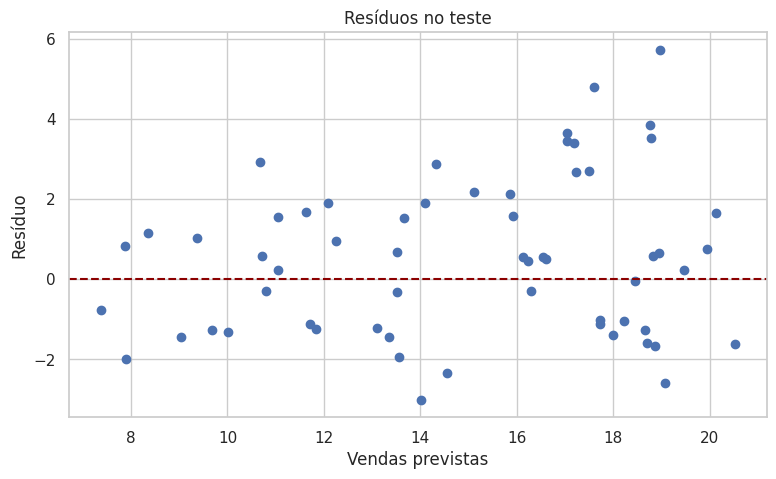

In [27]:
residuos_pub = y_pub_teste - prev_pub
plt.scatter(prev_pub, residuos_pub)
plt.axhline(0, color="darkred", linestyle="--")
plt.xlabel("Vendas previstas")
plt.ylabel("Resíduo")
plt.title("Resíduos no teste")
plt.show()

### Análise dos resíduos no teste

Os resíduos aparecem acima e abaixo de zero. Valores positivos indicam que o modelo subestimou as vendas; valores negativos indicam que as superestimou.

Nas previsões mais altas, especialmente entre 17 e 19 mil unidades, observa-se maior dispersão dos resíduos, com alguns erros positivos elevados. Isso sugere que a variabilidade dos erros pode não ser constante, embora o gráfico isolado não confirme essa hipótese.

Mesmo com R² de 0,7921, o modelo apresenta limitações: algumas observações têm erros consideráveis, e o investimento em TV sozinho não representa toda a variação das vendas.

## 10. Uma nova previsão - Considerando nos valores em investimento na tv
Altere o investimento abaixo. Confira se está dentro do intervalo observado. O resultado é uma estimativa pontual, com incerteza, e não uma garantia de vendas.

In [ ]:
investimento_tv = 100.0 # Altere este valor
entrada_pub = pd.DataFrame({"TV": [investimento_tv]})
print("Intervalo observado de TV:", publicidade["TV"].min(), "a", publicidade["TV"].max())
print(f"Vendas previstas: {modelo_publicidade.predict(entrada_pub)[0]:.2f}")

Intervalo observado de TV: 0.7 a 296.4
Vendas previstas: 11.64


### Previsão para um investimento em TV

O modelo treinado pode estimar as vendas para um valor informado de investimento em TV. Neste exemplo, **TV = 100** corresponde a **US$ 100 mil**.

O método `predict()` aplica a equação ajustada e retorna uma previsão de aproximadamente **12,40 mil unidades vendidas**.

O intervalo observado mostra os valores mínimo e máximo de investimento presentes na base. Previsões fora desse intervalo são extrapolações e exigem maior cautela.


## 11. Resultados estatísticos no treino
O statsmodels acrescenta a constante explicitamente. O resumo apresenta coeficientes, intervalos e testes. P-valores dependem dos pressupostos e não medem relevância gerencial nem comprovam causalidade. Normalidade de X ou Y não é requisito para ajustar mínimos quadrados; para inferência clássica em amostras pequenas, a hipótese normal se refere aos erros condicionais.

In [29]:
modelo_publicidade = LinearRegression()
modelo_publicidade.fit(X_pub_treino, y_pub_treino)

ols_pub = sm.OLS(
    y_pub_treino,
    sm.add_constant(X_pub_treino)
).fit()

print("Scikit-learn:")
print("Intercepto:", modelo_publicidade.intercept_)
print("Coeficiente de TV:", modelo_publicidade.coef_[0])

print("\nStatsmodels:")
print(ols_pub.params)

print(ols_pub.summary())

Scikit-learn:
Intercepto: 6.948683200001357
Coeficiente de TV: 0.054545752915907963

Statsmodels:
const    6.948683
TV       0.054546
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.52e-52
Time:                        18:31:03   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [

### Interpretação do relatório OLS

A regressão foi ajustada com **140 observações de treino**, resultando na equação:

$$
\widehat{\text{Vendas}} = 6{,}9897 + 0{,}0465 \times \text{TV}
$$

O **R² de 0,613** indica que o modelo explica aproximadamente **61,3% da variação das vendas no treino**. O R² ajustado de **0,611** considera a quantidade de variáveis explicativas.

O coeficiente de TV é **positivo e estatisticamente significativo**, com valor-p inferior a 0,001. Sob as hipóteses do modelo, há evidência de associação linear entre investimento em TV e vendas. O valor exibido como `0.000` resulta do arredondamento, não significa probabilidade zero.

Cada **US$ 1.000 adicionais em TV** estão associados a aproximadamente **46,5 unidades adicionais nas vendas previstas**. O intervalo de confiança de 95% para esse coeficiente vai de **0,040 a 0,053 mil unidades**.

O teste F apresenta valor-p de **2,84 × 10⁻³⁰**, indicando que o modelo com TV melhora o ajuste em relação a um modelo apenas com intercepto.

Os testes Omnibus e Jarque-Bera apresentam valores-p superiores a 0,05, sem evidência suficiente para rejeitar a normalidade dos erros. Isso não comprova normalidade nem garante boas previsões.

O relatório utiliza erros padrão convencionais (`nonrobust`), cuja validade depende das hipóteses sobre os erros, incluindo variância constante. A análise dos resíduos e a avaliação no teste continuam necessárias.